In [4]:
import json
import os
from pathlib import Path
import numpy as np
import torch
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 6})

import tqdm

import sys
sys.path.append('..')

import warnings
warnings.filterwarnings("ignore")

from omegaconf import OmegaConf

from probssl.data.base import prepare_data
from probssl.methods import METHODS
from probssl.utils.offline_model_eval import get_states_and_decodings

from probssl.data.dot_motion import get_video_frames, save_videos_as_gifs_and_pdfs

# seed everything
from lightning.pytorch import seed_everything

In [5]:
n = -1

def get_loader(model_name):
    seed_everything(3, workers=True)

    folder_name = "../trained_models/" + model_name + "/"
    # get name of the most recent model by folder creation time
    name = sorted(os.listdir(folder_name), key=lambda x: os.path.getctime(os.path.join(folder_name, x)))[n]

    pretrained_checkpoint_dir = folder_name + name
    args_file = os.path.join(pretrained_checkpoint_dir, "args.json")
    args = json.load(open(args_file, "r"))
    cfg = OmegaConf.create(args)
    cfg.data.settings.num_train_sequences = 1 
    cfg.data.settings.num_test_sequences = 32 

    # prepare data
    _, val_loader = prepare_data(cfg)

    return val_loader

def load_model_and_data(model_name, val_loader):
    seed_everything(3, workers=True)

    folder_name = "../trained_models/" + model_name + "/"
    # get name of the most recent model by folder creation time
    name = sorted(os.listdir(folder_name), key=lambda x: os.path.getctime(os.path.join(folder_name, x)))[n]
    print("Loading model from folder:", name)

    pretrained_checkpoint_dir = folder_name + name
    args_file = os.path.join(pretrained_checkpoint_dir, "args.json")
    args = json.load(open(args_file, "r"))
    cfg = OmegaConf.create(args)

    # build paths
    ckpt_dir = Path(pretrained_checkpoint_dir)  
    args_path = ckpt_dir / "args.json"
    ckpt_path = [ckpt_dir / ckpt for ckpt in os.listdir(ckpt_dir) if ckpt.endswith(".ckpt")][0]

    # load arguments
    with open(args_path) as f:
        method_args = json.load(f)
    cfg = OmegaConf.create(method_args)
    cfg.optimizer.batch_size = 8 # set batch size to 8 for evaluation

    # build the model
    model = (
        METHODS[method_args["method"]]
        .load_from_checkpoint(ckpt_path, strict=False, cfg=cfg)
    )

    # move model to the gpu
    device = "cuda:0"
    model = model.to(device)

    # get images and features
    data, labels, latents, decodings = get_states_and_decodings(device, model, val_loader)

    return data, labels, latents, decodings, model, cfg


In [ ]:
# model name is 
model_name = "qalmanSSL_wobbly_knn"
# model_name = "qalmanSSL_wobbly_stopgrad"
model_name = "qalmanSSL_wobbly_kde"
model_name = "qalmanSSL_wobbly_logdet"
loader = get_loader(model_name)
data, labels, latents, decodings, model, cfg = load_model_and_data(model_name, loader)


Seed set to 3
100%|██████████| 99/99 [00:00<00:00, 1786.44it/s]


Pre-generating videos...


1it [00:00, 17.13it/s]
100%|██████████| 99/99 [00:00<00:00, 2478.02it/s]


Pre-generating videos...


32it [00:01, 19.27it/s]
Seed set to 3


Loading model from folder: 20260114_142155_y49c5oj7


In [7]:
# plot settings
P_height = 0.7
P_width = 3
plot_folder = "plots/paper/"
Path(plot_folder).mkdir(parents=True, exist_ok=True)

In [8]:
# filter hidden states and decodings for a single example
filtered_keys = filter(lambda key: key not in ["hidden_states"], latents[0].keys())

batch_ind = 0
video_ind = 0
model_examples = {}
data_i = data[batch_ind][video_ind]
labels_i = {key: labels[batch_ind][key][video_ind] for key in labels[batch_ind].keys()}
latents_i = {key: latents[batch_ind][key][video_ind] for key in filtered_keys}
decodings_i = {key: decodings[batch_ind][key][video_ind] for key in decodings[batch_ind].keys()}
model_examples[model_name] = (data_i, labels_i, latents_i, decodings_i)

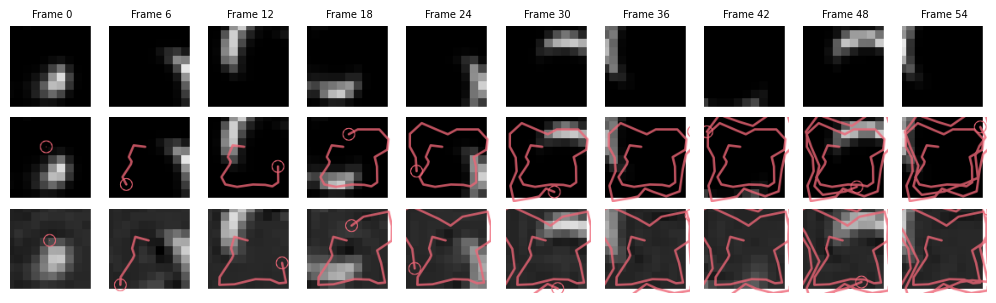

In [9]:

video = data_i.cpu().numpy()
pos = labels_i["pos"].cpu().numpy()
noise_level = labels_i["noise_level"].cpu().numpy()
frames = get_video_frames(video, pos, pointer=False, colormap="gray")
frames_pointer = get_video_frames(video, pos, pointer=True, colormap="gray")

image_decoding = decodings_i["observations"].cpu().numpy()
position_decoding = decodings_i["pos"].cpu().numpy()
frames_model = get_video_frames(image_decoding, position_decoding, pointer=True, colormap="gray")

# plot the video
n_frames = 10
skipframes = 6
fig, axes = plt.subplots(3, n_frames, figsize=(n_frames * 1, 3))
for i in range(n_frames):
    axes[0,i].imshow(frames[i * skipframes])
    axes[0,i].axis("off")
    axes[0,i].set_title(f"Frame {i * skipframes}")
    axes[1,i].imshow(frames_pointer[i * skipframes])
    axes[1,i].axis("off")
    axes[2,i].imshow(frames_model[i * skipframes])
    axes[2,i].axis("off")
plt.tight_layout()
plt.savefig(plot_folder + f"circular_motion_videos_{model_name}_example{video_ind}.pdf", dpi=300)


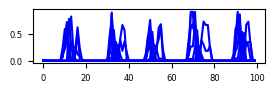

In [10]:
# plot video values over time
time = np.arange(video.shape[0])
fig, axes = plt.subplots(1, 1, figsize=(P_width, P_height), sharex=True)
axes.plot(time, video[:,0:10], label="True x", color="blue")
plt.show()


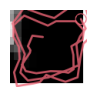

In [11]:
# plot single example trajectori
plt.figure(figsize=(1, 1))
plt.imshow(frames_pointer[i * skipframes])
plt.axis("off")
plt.savefig(plot_folder + f"circular_motion_trajectory_{model_name}_example{video_ind}.pdf", dpi=300)

In [ ]:

pos = labels_i["pos"].cpu().numpy()
fig, ax = plt.subplots(2, 1, figsize=(P_width*1.1, P_height*2))
ax[0].plot(pos[:, 0], 'orange', label='Ground Truth Pos.')
ax[1].plot(pos[:, 1], 'orange', label='Ground Truth Pos.')

estimates = latents_i["inferences"].cpu().numpy() 
pos_inferred = labels_i["pos"].cpu().numpy()
# plot decodings of labels
pos_decoding_matrix = model.decoder.decoders["pos"].linear.weight.data.cpu().numpy()
bias = model.decoder.decoders["pos"].linear.bias.data.cpu().numpy()
pos_decoding = (pos_decoding_matrix @ estimates.T).T + bias
ax[0].plot(pos_decoding[:, 0], 'green', label='Est. Pos.')
ax[1].plot(pos_decoding[:, 1], 'green', label='Est. Pos.')
    
ax[0].legend(loc='upper left', bbox_to_anchor=(1, 1), frameon=False)
ax[0].set_ylim(-3,3)
ax[1].set_ylim(-3,3)
ax[0].set_xlim(0, 50)
ax[1].set_xlim(0, 50)
ax[1].set_xlabel('Time')
ax[0].set_ylabel(r'x Position')
ax[1].set_ylabel(r'y Position')
ax[0].set_xticks([])
ax[0].spines['top'].set_visible(False)
ax[0].spines['right'].set_visible(False)
ax[0].spines['bottom'].set_visible(False)
ax[1].spines['top'].set_visible(False)
ax[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(plot_folder + "position_estimates_square_qalmanSSL.pdf", bbox_inches='tight')

In [ ]:
# r2 score
from sklearn.metrics import r2_score
r2 = r2_score(pos, pos_decoding)
print("R2 score for position decoding:", r2)

In [14]:
# raster of all positions from x,y = -lim to lim
lim = 2
X, Y = np.meshgrid(np.linspace(-lim, lim, 50), np.linspace(-lim, lim, 50))
pos_all = torch.tensor(np.stack([X.ravel(), Y.ravel()], axis=-1))

images_all = []
for i in tqdm.tqdm(range(pos_all.shape[0])):
    img = loader.dataset._create_img_from_pos(pos_all[i], 0.0, img_dim=(10,10))
    images_all.append(img.squeeze(0).numpy())
images_all = np.stack(images_all, axis=0)

100%|██████████| 2500/2500 [00:01<00:00, 1902.54it/s]


In [15]:
# create new qualmanSSL model
from probssl.methods import METHODS
new_model = METHODS[model.cfg.method](model.cfg)


In [16]:
# get encoded features for all images
latents_all_new = []
latents_all = []
model.cpu()
new_model.cpu()
for img in images_all:
    img_tensor = torch.from_numpy(img.reshape(-1)).unsqueeze(0).float()
    with torch.no_grad():
        latent_new = new_model.encoder.encoder(img_tensor)
        latent = model.encoder.encoder(img_tensor)

    latents_all.append(latent.cpu().numpy().squeeze(0))
    latents_all_new.append(latent_new.cpu().numpy().squeeze(0))

# color array
colors = np.zeros((pos_all.shape[0], 3))
normed_pos = (pos_all - pos_all.min()) / (pos_all.max() - pos_all.min()) 
for i in range(pos_all.shape[0]):
    colors[i, 0] = normed_pos[i, 0].item()
    colors[i, 1] = normed_pos[i, 1].item()
    colors[i, 2] = 0.5

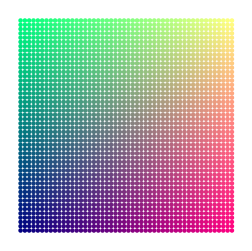

In [17]:

# plot positions in latent space color coded by x,y position
plt.figure(figsize=(P_width, P_width))
latents_all = np.stack(latents_all, axis=0)
sc = plt.scatter(pos_all[:, 0], pos_all[:, 1], c=colors, s=5)
# remove all spines
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['bottom'].set_visible(False)
plt.gca().spines['left'].set_visible(False)
# remove axis ticks
plt.xticks([])
plt.yticks([])
plt.savefig(plot_folder + f"qalmanSSL_latent_space_positions.pdf", dpi=300)

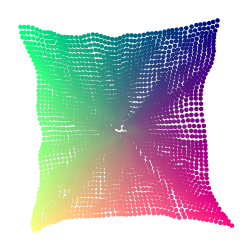

In [18]:


# # # pca 
# from sklearn.decomposition import PCA
# pca = PCA(n_components=2)
# latents_all_pca = pca.fit_transform(latents_all)

# find best decoder to position
# from sklearn.linear_model import LinearRegression
# reg = LinearRegression().fit(latents_all, pos_all.numpy())
# pos_decoded = reg.predict(latents_all)

# plot positions in latent space color coded by x,y position
plt.figure(figsize=(P_width, P_width))
latents_all = np.stack(latents_all, axis=0)
sc = plt.scatter(latents_all[:, 0], latents_all[:, 1], c=colors, s=5)
# sc = plt.scatter(latents_all_pca[:, 0], latents_all_pca[:, 1], c=colors, s=5)
# sc = plt.scatter(pos_decoded[:, 0], pos_decoded[:, 1], c=colors, s=5)
# remove all spines
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['bottom'].set_visible(False)
plt.gca().spines['left'].set_visible(False)
# remove axis ticks
plt.xticks([])
plt.yticks([])
plt.savefig(plot_folder + f"qalmanSSL_latent_space_after_learning.pdf", dpi=300)


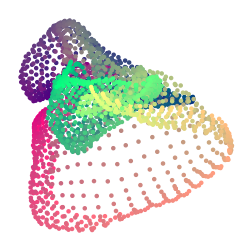

In [19]:
# plot positions in latent space color coded by x,y position
plt.figure(figsize=(P_width, P_width))
latents_all_new = np.stack(latents_all_new, axis=0)
sc = plt.scatter(latents_all_new[:, 0], latents_all_new[:, 1], c=colors, s=5)
# remove all spines
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['bottom'].set_visible(False)
plt.gca().spines['left'].set_visible(False)
# remove axis ticks
plt.xticks([])
plt.yticks([])
plt.savefig(plot_folder + f"qalmanSSL_latent_space_before_learning.pdf", dpi=300)